The code in this notebook extracts oncell spike times from abf files and performs initial analyses on AP timings and rates relative to uncaging stimulus onset. It stores this data as a pickle file that is used to make summary graphs in the accompanying notebook. After generating the pickle file there are two cells to generate the example traces shown in the manuscript figure. The code could be used to visualize other cells by changing the cell_id and sweep number. The final graph is not included in the notebook but illustrates how one could visualize extracted spike times and features with the data.

In [1]:
from signal_processing import *
from util import *

from ast import literal_eval
import matplotlib.pyplot as plt
import pyabf
import numpy as np
import pickle
import pandas as pd
import sys
from datetime import datetime, timedelta
from pathlib import Path
import scipy.signal as signal
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import linregress

%matplotlib ipympl

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

# Optional: Set a default font size
plt.rcParams["font.size"] = 10

In [2]:
def get_gaussian_thresh(trace, scale_factor = 4, n_bins=200):
    y_hist, x_hist = np.histogram(trace, bins=n_bins)
    x_adj = x_hist[:-1] + (x_hist[1] - x_hist[0])/2.
    peak_y = np.max(y_hist)
    initial_guesses = [peak_y, 0, np.std(trace)]
    popt, pcov = curve_fit(gaussian, x_adj, y_hist, p0=initial_guesses)
    gauss_thresh = popt[1] + scale_factor * abs(popt[2])
    return gauss_thresh


def find_oncell_spikes(abf, hi_pass_f = 50, low_pass_f=1000, peak_thresh=None, sd_factor=4):

    v = abf.sweepY
    t = abf.sweepX
    dt = t[1] -t[0]
    
    ##minimum time between spikes (s)
    min_isi_t = 0.003
    min_p = min_isi_t/dt
    
    min_width = 0.0005
    
    min_w_p = min_width/dt
    
    ##window for spike features
    pre_t = 0.001
    post_t = 0.003
    
    pre_p = int(pre_t/dt)
    post_p = int(post_t/dt)

    v_filt = bessel_filter(v, t, hi_pass_f, f_type="high")
    v_filt = bessel_filter(v_filt, t, low_pass_f, f_type="low")
    dvdt_filt = time_derivative(v_filt, t)
    g_thresh = get_gaussian_thresh(v_filt, scale_factor=5)
    dv_thresh = get_gaussian_thresh(dvdt_filt, scale_factor=5)
    #print (f"dv_thresh {dv_thresh}")
    
    if peak_thresh == None:
        u = np.mean(v_filt)
        sd = np.std(v_filt)
        peak_thresh = u + sd_factor * sd
    buffer_p = 100
    #v_peak_ps, _ = find_peaks(v_filt[buffer_p:-buffer_p], height=peak_thresh, distance=min_p, width=min_w_p)
    v_peak_ps, _ = find_peaks(v_filt[buffer_p:-buffer_p], height=g_thresh, distance=min_p, width=min_w_p)
    v_peak_ps += buffer_p
    v_peaks = v[v_peak_ps]
    v_heights = v_filt[v_peak_ps]
    v_peak_times = t[v_peak_ps]
    n_peaks = len(v_peak_ps)
    
    
    v_troughs = np.zeros(n_peaks)
    v_trough_times = np.zeros(n_peaks)
    dv_peaks = np.zeros(n_peaks)
    dv_peak_times = np.zeros(n_peaks)
    dv_troughs = np.zeros(n_peaks)
    dv_trough_times = np.zeros(n_peaks)
    v_pres = np.zeros(n_peaks)
    
    
    it = 0
    
    for p in v_peak_ps:
        end_p = p + post_p
        start_p = p - pre_p
        ##back up a little further to find pre spike voltage
        pre_start = start_p - pre_p
        
        ap_chunk = v[start_p:end_p]
        dv_chunk = dvdt_filt[start_p:end_p]
        pre_ap_chunk = v[pre_start:start_p]
        
        bs = basic_stats(ap_chunk)
        v_peaks[it] = bs['max_val']
        v_peak_times[it] = t[bs['max_p'] + start_p]
        v_troughs[it] = bs['min_val']
        v_trough_times[it] = t[bs['min_p'] + start_p]
    
        bs = basic_stats(dv_chunk)
        dv_peaks[it] = bs['max_val']
        dv_peak_times[it] = t[bs['max_p'] + start_p]
        dv_troughs[it] = bs['min_val']
        dv_trough_times[it] = t[bs['min_p'] + start_p]
    
        pre_ap_v = np.median(pre_ap_chunk)
        v_pres[it] = pre_ap_v
        
        
        it += 1

    spike_feat_dict = {
        'dv_peak_times' : dv_peak_times,
        'dv_peaks' : dv_peaks,
        'v_peaks' : v_peaks,
        'v_peak_times' : v_peak_times,
        'v_troughs' : v_troughs,
        'v_trough_times': v_trough_times,
        'v_pres' : v_pres,
        'dv_troughs' : dv_troughs,
        'dv_trough_times' : dv_trough_times,
        'v_height': v_heights
    
    }
    
    spike_df = pd.DataFrame(spike_feat_dict)
    spike_df['v_height_raw'] = spike_df['v_peaks'] - spike_df['v_pres']
    spike_df['trough_depth'] = spike_df['v_troughs'] - spike_df['v_pres']
    max_height = np.max(spike_df['v_height'])
    min_depth = np.min(spike_df['trough_depth'])
    max_dv = np.max(spike_df['dv_peaks'])
    min_dv = np.min(spike_df['dv_troughs'])
    f_spike_df = spike_df[(spike_df['v_height'] > max_height/3.) & (spike_df['v_height'] > 0.005)]
    f_spike_df = f_spike_df[f_spike_df['v_trough_times'] > f_spike_df['v_peak_times']]
    f_spike_df = f_spike_df[f_spike_df['dv_peaks'] > 0.1*max_dv]
    #f_spike_df = f_spike_df[(f_spike_df['dv_peaks'] > dv_thresh) & (f_spike_df['dv_troughs'] < -0.75*dv_thresh)]
    
    f_spike_df = f_spike_df[f_spike_df['trough_depth'] < 0.05*min_depth]
    f_spike_df.reset_index(inplace=True, drop=True)
    f_spike_df['isi'] = f_spike_df['v_peak_times'].diff()
    f_spike_df['inst_f'] = 1./f_spike_df['isi']
    #return filtered spike dataframe and initial spike_df
    return f_spike_df, spike_df

In [5]:
gsheetkey = "1_MJSSOUke04-oIj4biDR9Y6DnXDvMyq6Y8XNgiqMmgI"

sheet_name = "cells"

url=f'https://docs.google.com/spreadsheet/ccc?key={gsheetkey}&output=xlsx'
cell_manifest = pd.read_excel(url,sheet_name=sheet_name)
cell_manifest['file_list'] = cell_manifest['file_list'].apply(literal_eval)

elder_uv_cal = pd.read_excel(url,sheet_name="elder_uv_cal")
big_uv_cal = pd.read_excel(url, sheet_name='big_uv_cal')
cal_dict = {'elder':elder_uv_cal,
            'big': big_uv_cal}

In [18]:
cell_manifest = pd.read_excel('data/DAN_glu_uncaging.xlsx', sheet_name='cells')
cell_manifest['file_list'] = cell_manifest['file_list'].apply(literal_eval)
cell_manifest

,cell_name,mCherry_label,rig,folder_path,file_list,cell_notes,mouse_treatment,gap_free_file,gf_abfsweep,gf_min,...,gf_rate,ap_peak,ap_rise_t,ap_trough,ap_peak_trough_t,ap_fwhm,ap_udr,day_id,slice_id,sex
0,250917_cell1_TH,positive,elder,data/elder_rig/2025_09_17/,"[2025_09_17_0002.abf, 2025_09_17_0004.abf, 202...",NaN,sham,2025_09_17_0001.abf,NaN,NaN,...,4.769847,0.656533,0.00030,-0.373900,0.00090,0.00040,1.080485,d250917,d250917_s0,male
1,250917_cell2_TH,positive,elder,data/elder_rig/2025_09_17/,"[2025_09_17_0009.abf, 2025_09_17_0010.abf]",NaN,sham,2025_09_17_0011.abf,NaN,26.0,...,5.606004,0.490057,0.00030,-0.265755,0.00100,0.00030,1.057102,d250917,d250917_s0,male
2,250917_cell3_TH,positive,elder,data/elder_rig/2025_09_17/,[2025_09_17_0015.abf],high background rate,sham_skip,2025_09_17_0015.abf,0.0,0.0,...,23.675644,0.285393,0.00045,-0.275149,0.00090,0.00050,0.683702,d250917,d250917_s0,male
3,250917_cell4_TH,positive,elder,data/elder_rig/2025_09_17/,[2025_09_17_0016.abf],high/variable background rate,sham,2025_09_17_0017.abf,NaN,NaN,...,5.536024,0.673113,0.00070,-0.374444,0.00180,0.00080,1.200219,d250917,d250917_s0,male
4,250917_cell5_TH,positive,elder,data/elder_rig/2025_09_17/,[2025_09_17_0019.abf],high background rate,sham,2025_09_17_0020.abf,NaN,NaN,...,3.945803,1.588427,0.00050,-0.870922,0.00140,0.00060,1.116795,d250917,d250917_s1,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,251003_cell10_TH,positive,elder,data/elder_rig/2025_10_03/,[2025_10_03_0023.abf],NaN,sham,2025_10_03_0022.abf,NaN,NaN,...,2.082170,0.466133,0.00050,-0.239174,0.00150,0.00070,0.778033,d251003,d251003_s1,male
64,251003_cell11_TH,positive,elder,data/elder_rig/2025_10_03/,[2025_10_03_0026.abf],NaN,sham,2025_10_03_0027.abf,NaN,NaN,...,1.792412,0.316627,0.00050,-0.203491,0.00145,0.00060,0.759449,d251003,d251003_s1,male
65,251003_cell12_TH,positive,elder,data/elder_rig/2025_10_03/,[2025_10_03_0028.abf],NaN,sham,2025_10_03_0029.abf,NaN,NaN,...,1.789023,0.548090,0.00045,-0.297446,0.00160,0.00065,0.909206,d251003,d251003_s1,male
66,251003_cell13_TH,positive,elder,data/elder_rig/2025_10_03/,[2025_10_03_0030.abf],NaN,sham,2025_10_03_0031.abf,NaN,NaN,...,6.631263,1.696601,0.00040,-0.992825,0.00190,0.00070,2.217400,d251003,d251003_s2,male


In [36]:
def get_led_powers(cell_manifest, cell_id, cal_df):
    cell_df = cell_manifest[cell_manifest['cell_name'] == cell_id]
    folder_path = cell_df['folder_path'].iloc[0]
    
    file_list = cell_df['file_list'].iloc[0]
    led_dict = {}
    for file in file_list:
        abf_file_path = folder_path + file
        
        led_file = file[:-4]+"_led_powers.csv"
        led_file_path = folder_path + led_file
        led_df = pd.read_csv(led_file_path)
        led_df = pd.merge(led_df, cal_df, how='left', left_on="UV_perc", right_on="UV_perc")
        led_dict[file] = led_df

    return led_dict
        
def all_cell_spikes(cell_manifest, cell_id, cal_dict, sd_factor=4):
    ##get metadata for this cell
    cell_df = cell_manifest[cell_manifest['cell_name'] == cell_id]
    folder_path = cell_df['folder_path'].iloc[0]
    file_list = cell_df['file_list'].iloc[0]
    rig = cell_df['rig'].iloc[0]

    ##df to convert led percentage to power
    cal_df = cal_dict[rig]
    ##a dictionary of keys/filenames with values/dataframes containing led %ages and powers
    led_dict = get_led_powers(cell_manifest, cell_id, cal_df)
    
    cell_spike_dict = {}
    cell_dict = {}
    sweep_feat_list = []
    for file in file_list:
        file_path = folder_path + file
        led_df = led_dict[file]
        abf = pyabf.ABF(file_path)
        
        for sweep in range(abf.sweepCount):
            sweep_dict = {}
            sweep_name = file + "_sweep_" + str(sweep)
            abf.setSweep(sweep)
            spike_feat_df, _ = find_oncell_spikes(abf, sd_factor=sd_factor)
            cell_spike_dict[sweep_name] = spike_feat_df
            t = abf.sweepX
            dig = abf.sweepD(0)
            dt = t[1] - t[0]
            dig_onset = get_rising_edges(dig, 0.5)[0] *dt
            dig_offset = get_falling_edges(dig, 0.5)[0] *dt
            LED_perc = led_df['UV_perc'][sweep]
            LED_power = led_df['power_40x'][sweep]
            sweep_notes = str(led_df['notes'][sweep])
            sweep_dict['sweep_name'] = sweep_name
            sweep_dict['UV_perc'] = LED_perc
            sweep_dict['UV_power'] = LED_power
            sweep_dict['sweep_notes'] = sweep_notes
            sweep_dict['dig_onset'] = dig_onset
            sweep_dict['dig_offset'] = dig_offset
            evoked_dict = evoked_features(spike_feat_df, dig_onset, dig_offset)
            
            if evoked_dict['spike1_rh'] > 1.5:
                print (sweep_name)
            sweep_dict.update(evoked_dict)
            
            sweep_feat_list.append(sweep_dict)
            ##adding spike_df appending is intentional
            sweep_dict['spike_df'] = spike_feat_df
            cell_dict[sweep_name] = sweep_dict
        sweep_feat_df = pd.DataFrame(sweep_feat_list)
        sweep_feat_df = sweep_feat_df[~sweep_feat_df['sweep_notes'].str.contains('exclude', na=False)]
        cell_dict['sweep_feats'] = sweep_feat_df
            
    return cell_dict



def get_n_spike_param(df, n_spike, param):
    df_reset = df.reset_index(drop=True)
    max_i = len(df_reset)
    if n_spike == 0:
        val = np.nan
    elif n_spike > max_i:
        val = np.nan
    else:
        val = df_reset[param][n_spike-1]
    return val

def find_burst(sf_df, dig_onset, dig_offset, plot=False):
    pre_stim = sf_df[sf_df['v_peak_times'] < dig_onset]
    pre_stim_u = np.mean(pre_stim['inst_f'])
    pre_stim_sig = np.std(pre_stim['inst_f'])
    high_thresh = pre_stim_u + 2 * pre_stim_sig
    low_thresh = pre_stim_u - 2 * pre_stim_sig
    post_stim = sf_df[sf_df['v_peak_times'] > dig_onset]
    if plot:
        fig, ax = plt. subplots()
        ax.plot(sf_df['v_peak_times'], sf_df['inst_f'], marker='.', alpha=0.5)
        ax.plot([dig_onset, dig_offset], [0,0])
    print (f"pre stim firing rate: {pre_stim_u} +/- {pre_stim_sig} AP/s")
    
    post_stim_raised_f = post_stim[post_stim['inst_f'] > high_thresh]
    if len(post_stim_raised_f) == 0:
        print ("no raised rate found")
        burst_df = pd.DataFrame()
        if plot:
            plt.show()
        return 
    else:
        raised_f_i_start = post_stim_raised_f.index[0]
        raised_f_t_start = post_stim_raised_f['v_peak_times'].iloc[0]
    
        ##spikes after the start of increased rate, and below increased rate threshold
        post_stim_raised_end = post_stim[(post_stim['v_peak_times'] > raised_f_t_start) & (post_stim['inst_f'] < high_thresh)]
        if len(post_stim_raised_end) == 0:
            ## if inst rate never drops below high_thresh, stop will be last recorded spike
            raised_f_i_stop = post_stim_raised_f.index[-1]+1
        else:
            ##else the first spike
            raised_f_i_stop = post_stim_raised_end.index[0]
        burst_df = sf_df[raised_f_i_start:raised_f_i_stop]
        if plot:    
            ax.scatter(burst_df['v_peak_times'], burst_df['inst_f'], marker='.', c='red')
            plt.show()   
        return burst_df
    
def evoked_features(spike_df, dig_onset, dig_offset):
    pre_df = spike_df[spike_df['v_peak_times'] < dig_onset]
    if len(pre_df) > 1:
        pre_mean = np.mean(pre_df['inst_f'])
    elif len(pre_df) == 1:
        pre_mean = 1./dig_onset
    else:
        pre_mean = 0
    mean_height_pre = np.mean(pre_df['v_height'])
    mean_dv_pre = np.mean(pre_df['dv_peaks'])
    spike_df['height_norm'] = spike_df['v_height']/mean_height_pre
    spike_df['dv_norm'] = spike_df['dv_peaks']/mean_dv_pre
    spike_df['latency'] = spike_df['v_peak_times'] - dig_onset
    post_df = spike_df[spike_df['latency'] > 0]
    ms50_df = post_df[post_df['latency'] < 0.05]
    early_df = post_df[post_df['latency'] < 0.1]
    late_df = post_df[(post_df['latency'] > 0.1) & (post_df['latency'] < 0.2)]
    offset_df = post_df[(post_df['v_peak_times'] > dig_offset) & (post_df['v_peak_times'] < dig_offset + 0.1)]
    stim_df = spike_df[(spike_df['v_peak_times'] > dig_onset) & (spike_df['v_peak_times'] < dig_offset)]
    n_stim = len(stim_df)
    if n_stim == 0:
        stim_max = 0
        stim_mean = 0
        
    else:
        stim_max = np.max(stim_df['inst_f'])
        stim_mean = np.mean(stim_df['inst_f'])
        

    if n_stim > 1:
        stim_first = stim_df['inst_f'].iloc[1]
    else:
        stim_first = np.nan
    stim_first_isi = 1./stim_first 
    stim_min_latency = np.min(stim_df['latency'])
    stim_max_latency = np.max(stim_df['latency'])
    
    
    n_50ms = len(ms50_df)
    n_early = len(early_df)
    rh_early = np.mean(early_df['height_norm'])
    rh_late = np.mean(late_df['height_norm'])
    rdv_early = np.mean(early_df['dv_norm'])
    rdv_late = np.mean(late_df['dv_norm'])
    n_late = len(late_df)
    n_off = len(offset_df)
    rh_min = np.min(stim_df['height_norm'])
    dv_min = np.min(stim_df['dv_norm'])
    duration = stim_max_latency - stim_min_latency
    spike1_rh = get_n_spike_param(stim_df, 1, "height_norm")
    spike3_rh = get_n_spike_param(stim_df, 3, 'height_norm')
    spike5_rh = get_n_spike_param(stim_df, 5, 'height_norm')
    spike8_rh = get_n_spike_param(stim_df, 8, 'height_norm')
    spike10_rh = get_n_spike_param(stim_df, 10, 'height_norm')
    spike15_rh = get_n_spike_param(stim_df, 15, 'height_norm')
    spike20_rh = get_n_spike_param(stim_df, 20, 'height_norm')
    
    output_dict = {
        'stim_max' : stim_max,
        'stim_mean' : stim_mean,
        'stim_first': stim_first,
        'duration' : duration,
        'first_isi': stim_first_isi,
        'stim_max_latency': stim_max_latency,
        'stim_min_latency': stim_min_latency,
        'n_50ms': n_50ms,
        'n_early' : n_early,
        'n_late' : n_late,
        'n_stim' : n_stim,
        'n_off' : n_off,
        'rh_early': rh_early,
        'rh_late': rh_late,
        'rdv_early': rdv_early, 
        'rdv_late' : rdv_late,
        'pre_mean' : pre_mean,
        'rh_min': rh_min,
        'dv_min': dv_min,
        'spike1_rh': spike1_rh,
        'spike3_rh': spike3_rh,
        'spike5_rh': spike5_rh,
        'spike8_rh': spike8_rh,
        'spike10_rh': spike10_rh,
        'spike15_rh': spike15_rh,
        'spike20_rh': spike20_rh
    }
    return output_dict
    

def burst_features(burst_df, dig_onset):
    
    
    burst_mean = np.mean(burst_df['inst_f'])
    burst_max = np.max(burst_df['inst_f'])
    n_burst_APs = len(burst_df)
    burst_duration = max(burst_df['v_peak_times']) - min(burst_df['v_peak_times'])
    burst_latency = min(burst_df['v_peak_times']) - dig_onset

    bf_dict = {
        'burst_mean' : burst_mean,
        'burst_max' : burst_max,
        'burst_n_APs': n_burst_APs,
        'burst_duration':burst_duration,
        'burst_latency': burst_latency
    }
    return bf_dict
    

In [37]:
all_cell_dict = {}
for cell_id in cell_manifest['cell_name'].values:
    print (cell_id)
    cell_spike_dict = all_cell_spikes(cell_manifest, cell_id, cal_dict)
    all_cell_dict[cell_id] = cell_spike_dict

250917_cell1_TH
250917_cell2_TH
250917_cell3_TH
250917_cell4_TH
2025_09_17_0016.abf_sweep_1
2025_09_17_0016.abf_sweep_3
2025_09_17_0016.abf_sweep_13
250917_cell5_TH
250918_cell1_TH
250918_cell2_TH
250918_cell3_TH
250918_cell4_TH
250918_cell5_TH
250918_cell6_TH
250924_cell1_TH
250924_cell2_TH
250924_cell3_TH
250924_cell4_TH
250924_cell5_TH
250924_cell6_TH
250925_cell1_TH
250925_cell3_TH
250925_cell4_TH
250925_cell5_TH
250925_cell6_TH
250925_cell7_TH
250925_cell8_TH
250925_cell9_TH
250925_cell10_TH
250925_cell11_TH
250925_cell12_TH
250926_cell1_TH
250926_cell2_TH
250926_cell3_TH
250926_cell4_TH
250926_cell5_TH
250926_cell6_TH
250926_cell7_TH
250926_cell8_TH
250926_cell9_TH
250926_cell10_TH
250925_cell2_MC
250925_cell3_MC
250926_cell5_MC
250926_cell6_MC
250926_cell7_MC
2025_09_26_0007.abf_sweep_7
2025_09_26_0007.abf_sweep_8
251002_cell1_TH
251002_cell2_TH
251002_cell3_TH
2025_10_02_0010.abf_sweep_1
2025_10_02_0010.abf_sweep_2
2025_10_02_0011.abf_sweep_0
2025_10_02_0011.abf_sweep_1
2025_10

In [38]:
pickle_name = 'oncell_spike_dicts_20260317.pickle'
with open(pickle_name, 'wb') as handle:
    pickle.dump(all_cell_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

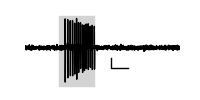

In [22]:
cell_id = "250924_cell3_TH"
sweep_i = 0
cell_df = cell_manifest[cell_manifest['cell_name'] == cell_id]
cell_dict = all_cell_dict[cell_id]



folder_path = cell_df['folder_path'].iloc[0]
file_list = cell_df['file_list'].iloc[0]
file = file_list[0]
filepath = folder_path +  file

sweep_name = file+"_sweep_"+str(sweep_i)
sweep_dict = cell_dict[sweep_name]
dig_on = sweep_dict['dig_onset']
dig_off = sweep_dict['dig_offset']

scale_x = [dig_off+0.1, dig_off+0.1, dig_off+0.2]
scale_y = [-0.1, -0.2, -0.2]

abf = pyabf.ABF(filepath)

abf.setSweep(sweep_i)


hi_pass_f = 50
low_pass_f = 1000

t = abf.sweepX
v = abf.sweepY
dig = abf.sweepD(0)
v_filt = bessel_filter(v, t, hi_pass_f, f_type="high")
v_filt = bessel_filter(v_filt, t, low_pass_f, f_type="low")
light_y = min(v_filt) - 0.02

fb_min = min(v_filt) * 1.1
fb_max = max(v_filt) * 1.1

spike_feat_df, raw_df = find_oncell_spikes(abf, sd_factor=4.)


fig, ax = plt.subplots(figsize=(2, 1))
ax.plot(scale_x, scale_y, c='black', lw=1)
ax.plot(t, v_filt, c='black', zorder=3, lw=1)
#ax.scatter(spike_feat_df['v_peak_times'], spike_feat_df['v_height'], marker='^',zorder=2)
ax.fill_between([dig_on, dig_off], [fb_min, fb_min], [fb_max, fb_max], color='lightgrey', zorder=1)
#ax.plot([dig_on, dig_off], [light_y, light_y], c='violet')
ax.set_xlim([dig_on-0.2, dig_off+0.5])
ax.spines[['right', 'top']].set_visible(False)
ax.set_axis_off()
#plt.savefig('sham_example_250924_cell3_TH.svg')
plt.show()


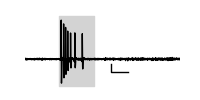

In [23]:
cell_id = "250926_cell1_TH"
sweep_i = 5
cell_df = cell_manifest[cell_manifest['cell_name'] == cell_id]
cell_dict = all_cell_dict[cell_id]


plt.close('all')
folder_path = cell_df['folder_path'].iloc[0]
file_list = cell_df['file_list'].iloc[0]
file = file_list[0]
filepath = folder_path +  file

sweep_name = file+"_sweep_"+str(sweep_i)
sweep_dict = cell_dict[sweep_name]
dig_on = sweep_dict['dig_onset']
dig_off = sweep_dict['dig_offset']

abf = pyabf.ABF(filepath)

abf.setSweep(sweep_i)


hi_pass_f = 50
low_pass_f = 1000

t = abf.sweepX
v = abf.sweepY
dig = abf.sweepD(0)
v_filt = bessel_filter(v, t, hi_pass_f, f_type="high")
v_filt = bessel_filter(v_filt, t, low_pass_f, f_type="low")
fb_min = min(v_filt) * 1.1
fb_max = max(v_filt) * 1.1
light_y = min(v_filt) - 0.02

spike_feat_df, raw_df = find_oncell_spikes(abf, sd_factor=4.)

scale_x = [dig_off+0.1, dig_off+0.1, dig_off+0.2]
scale_y = [-0.2, -0.5, -0.5]

fig, ax = plt.subplots(figsize=(2, 1))
ax.plot(scale_x, scale_y, c='black', lw=1)
ax.plot(t, v_filt, c='black', zorder=3, lw=1)
#ax.scatter(spike_feat_df['v_peak_times'], spike_feat_df['v_height'], marker='^',zorder=2)
ax.fill_between([dig_on, dig_off], [fb_min, fb_min], [fb_max, fb_max], color='lightgrey', zorder=1)
#ax.plot([dig_on, dig_off], [light_y, light_y], c='violet')
ax.set_xlim([dig_on-0.2, dig_off+0.5])
ax.spines[['right', 'top']].set_visible(False)
ax.set_axis_off()
#plt.savefig('sni_example_250926_cell1_TH.svg')
plt.show()


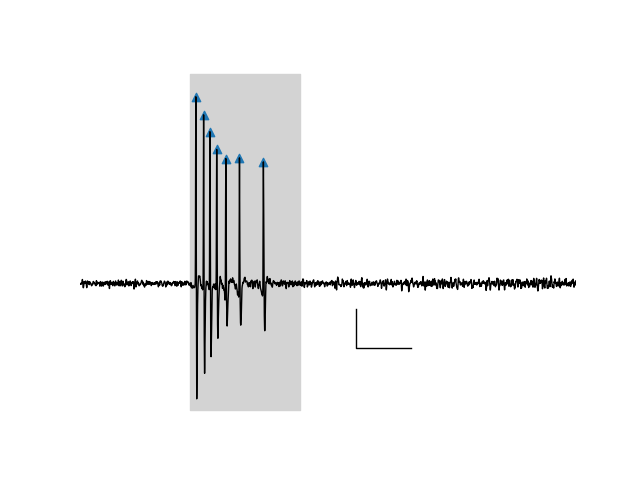

In [25]:
fig, ax = plt.subplots()
ax.plot(scale_x, scale_y, c='black', lw=1)
ax.plot(t, v_filt, c='black', zorder=3, lw=1)
ax.scatter(spike_feat_df['v_peak_times'], spike_feat_df['v_height'], marker='^',zorder=2)
ax.fill_between([dig_on, dig_off], [fb_min, fb_min], [fb_max, fb_max], color='lightgrey', zorder=1)
#ax.plot([dig_on, dig_off], [light_y, light_y], c='violet')
ax.set_xlim([dig_on-0.2, dig_off+0.5])
ax.spines[['right', 'top']].set_visible(False)
ax.set_axis_off()
#plt.savefig('sni_example_250926_cell1_TH.svg')
plt.show()